<a href="https://colab.research.google.com/github/EzeGB/PythonExcercises/blob/practica3/practica3DiplomadoCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔹 Ejercicio 1: Distribución Binomial
Se lanza una moneda cuatro veces consecutivas:
* Mostrar en pantalla todas las combinaciones posibles de obtener cara dos veces.
* Calcular la probabilidad de que se obtenga cara al menos una vez.
* Generar un gráfico de la distribución probabilística.


Creamos una permutadora para 2 valores, asi obtenemos los valores posibles de resultados por cada n lanzamientos.

In [217]:
def permutadora(n):
    if n == 1:
        return [[0], [1]]
    else:
        resultado = []
        preliminares = permutadora(n-1)

        for x in preliminares:
            for z in [0, 1]:
                x.append(z)
                resultado.append(list(x))
                x.pop()
        return resultado

In [222]:
resultadoPermutado = permutadora(4)
print(resultadoPermutado)

[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1], [0, 1, 0, 0], [0, 1, 0, 1], [0, 1, 1, 0], [0, 1, 1, 1], [1, 0, 0, 0], [1, 0, 0, 1], [1, 0, 1, 0], [1, 0, 1, 1], [1, 1, 0, 0], [1, 1, 0, 1], [1, 1, 1, 0], [1, 1, 1, 1]]


Mapeamos las posibilidades

In [223]:
posibilidades = []
for indice,posibilidad in enumerate(resultadoPermutado):
    posibilidades.append('')
    for p in posibilidad:
        if p == 0:
            posibilidades[indice] += 'T' #Tails para cruz
        else:
            posibilidades[indice] += 'H' #heads para cara
print(posibilidades)

['TTTT', 'TTTH', 'TTHT', 'TTHH', 'THTT', 'THTH', 'THHT', 'THHH', 'HTTT', 'HTTH', 'HTHT', 'HTHH', 'HHTT', 'HHTH', 'HHHT', 'HHHH']


Imprimimos las posibilidades:

In [226]:
print('Combinaciones para obtener cara (H) exactamente 2 veces')
for p in posibilidades:
    if p.count('H') == 2:
        print(p)

Combinaciones para obtener cara (H) exactamente 2 veces
TTHH
THTH
THHT
HTTH
HTHT
HHTT


Calcular la probabilidad de que se obtenga cara al menos una vez.

In [232]:
from scipy.stats import binom
bin = binom(4, 0.5) #Cuatro lanzamientos, cada uno con 50% de sacar exito (H)
bin.cdf(4) - bin.cdf(0) ##Al menos una vez (o mas) menos las posibilidades de que no salga cara

np.float64(0.9375)

Generar un gráfico de la distribución probabilística.

<BarContainer object of 5 artists>

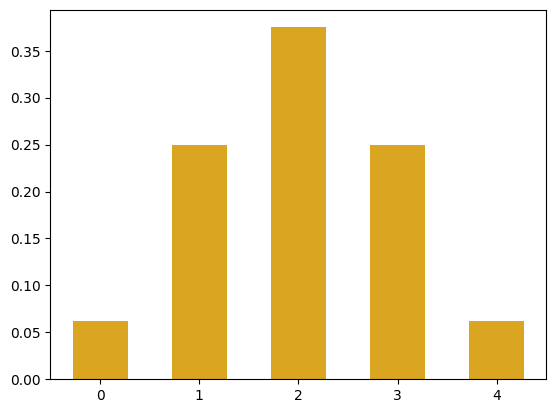

In [238]:
import numpy as np
import matplotlib.pyplot as plt

h = np.arange(0, 4 + 1)
prob = [bin.pmf(h) for h in h]

plt.bar(h, prob, width=0.55, color='goldenrod')